<span style='color:pink'> apply a winsorization technique </span>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from scipy.stats.mstats import  winsorize

In [4]:
df = sns.load_dataset('iris')

In [5]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


<Axes: ylabel='petal_length'>

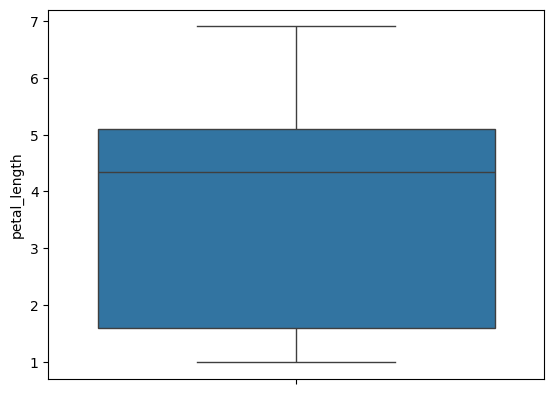

In [6]:
sns.boxplot(df['petal_length'])
# sns.boxplot(df['sepal_width'])
# sns.boxplot(df['petal_width'])

<Axes: ylabel='sepal_length'>

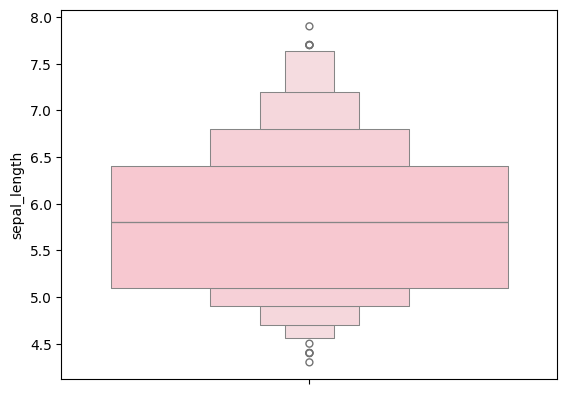

In [7]:
sns.boxenplot(df['sepal_length'],color='pink')

In [8]:
win = winsorize(df['sepal_length'],limits=[0.05,0.05])

In [9]:
df['winsorized_sepal_lenth'] = win

In [10]:
df

,sepal_length,sepal_width,petal_length,petal_width,species,winsorized_sepal_lenth
0,5.1,3.5,1.4,0.2,setosa,5.1
1,4.9,3.0,1.4,0.2,setosa,4.9
2,4.7,3.2,1.3,0.2,setosa,4.7
3,4.6,3.1,1.5,0.2,setosa,4.6
4,5.0,3.6,1.4,0.2,setosa,5.0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,6.7
146,6.3,2.5,5.0,1.9,virginica,6.3
147,6.5,3.0,5.2,2.0,virginica,6.5
148,6.2,3.4,5.4,2.3,virginica,6.2


<Axes: ylabel='winsorized_sepal_lenth'>

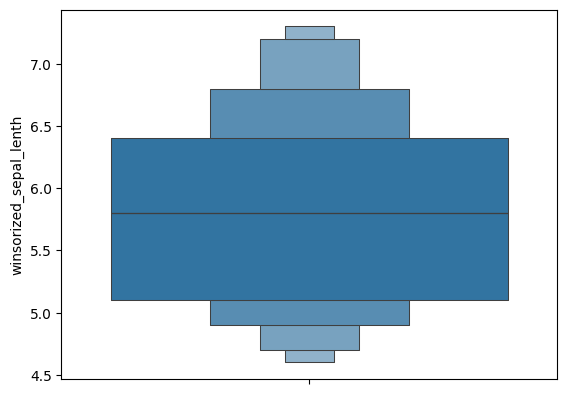

In [11]:
sns.boxenplot(df['winsorized_sepal_lenth'])

<Axes: xlabel='winsorized_sepal_lenth', ylabel='Density'>

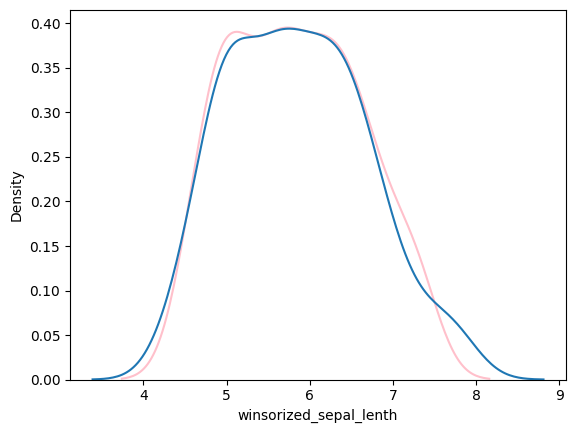

In [12]:
sns.kdeplot(df.winsorized_sepal_lenth,color='pink')
sns.kdeplot(df.sepal_length)

In [13]:
mean = df['sepal_length'].mean()
veriance = df['sepal_length'].std()

In [14]:
df['z_score'] = (df['sepal_length'] - mean) / veriance

In [63]:
outliers_data =  df[np.abs(df['z_score']) > 3 ]

In [64]:
outliers_data

,sepal_length,sepal_width,petal_length,petal_width,species,winsorized_sepal_lenth,z_score,cliped_sepal_length,log_sepal_length,robust_data


In [16]:
q1 = df['sepal_length'].quantile(0.25)
q3 = df['sepal_length'].quantile(0.75)

In [17]:
iqr = q1 - q3
print(iqr)

-1.3000000000000007


In [18]:
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

In [19]:
print(lower)
print(upper)

7.050000000000001
4.449999999999999


In [20]:
df[(df['sepal_length'] < lower) & (df['sepal_length'] > upper)]

,sepal_length,sepal_width,petal_length,petal_width,species,winsorized_sepal_lenth,z_score
0,5.1,3.5,1.4,0.2,setosa,5.1,-0.897674
1,4.9,3.0,1.4,0.2,setosa,4.9,-1.139200
2,4.7,3.2,1.3,0.2,setosa,4.7,-1.380727
3,4.6,3.1,1.5,0.2,setosa,4.6,-1.501490
4,5.0,3.6,1.4,0.2,setosa,5.0,-1.018437
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,6.7,1.034539
146,6.3,2.5,5.0,1.9,virginica,6.3,0.551486
147,6.5,3.0,5.2,2.0,virginica,6.5,0.793012
148,6.2,3.4,5.4,2.3,virginica,6.2,0.430722


In [21]:
clip_upper = df['sepal_length'].quantile(0.95)
clip_lower = df['sepal_length'].quantile(0.05)

In [22]:
print(clip_lower)
print(clip_upper)

4.6
7.254999999999998


In [35]:
outliers = df['cliped_sepal_length'] = df['sepal_length'].clip(clip_lower,clip_upper)

In [24]:
df

,sepal_length,sepal_width,petal_length,petal_width,species,winsorized_sepal_lenth,z_score,cliped_sepal_length
0,5.1,3.5,1.4,0.2,setosa,5.1,-0.897674,5.1
1,4.9,3.0,1.4,0.2,setosa,4.9,-1.139200,4.9
2,4.7,3.2,1.3,0.2,setosa,4.7,-1.380727,4.7
3,4.6,3.1,1.5,0.2,setosa,4.6,-1.501490,4.6
4,5.0,3.6,1.4,0.2,setosa,5.0,-1.018437,5.0
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,6.7,1.034539,6.7
146,6.3,2.5,5.0,1.9,virginica,6.3,0.551486,6.3
147,6.5,3.0,5.2,2.0,virginica,6.5,0.793012,6.5
148,6.2,3.4,5.4,2.3,virginica,6.2,0.430722,6.2


In [32]:
df['log_sepal_length'] = np.log1p(df['sepal_length'])

In [41]:
from sklearn.preprocessing import RobustScaler

In [42]:
robust = RobustScaler()

In [50]:
df['robust_data'] = robust.fit_transform(df[['sepal_length']])

In [51]:
df

,sepal_length,sepal_width,petal_length,petal_width,species,winsorized_sepal_lenth,z_score,cliped_sepal_length,log_sepal_length,robust_data
0,5.1,3.5,1.4,0.2,setosa,5.1,-0.897674,5.1,1.808289,-0.538462
1,4.9,3.0,1.4,0.2,setosa,4.9,-1.139200,4.9,1.774952,-0.692308
2,4.7,3.2,1.3,0.2,setosa,4.7,-1.380727,4.7,1.740466,-0.846154
3,4.6,3.1,1.5,0.2,setosa,4.6,-1.501490,4.6,1.722767,-0.923077
4,5.0,3.6,1.4,0.2,setosa,5.0,-1.018437,5.0,1.791759,-0.615385
...,...,...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,6.7,1.034539,6.7,2.041220,0.692308
146,6.3,2.5,5.0,1.9,virginica,6.3,0.551486,6.3,1.987874,0.384615
147,6.5,3.0,5.2,2.0,virginica,6.5,0.793012,6.5,2.014903,0.538462
148,6.2,3.4,5.4,2.3,virginica,6.2,0.430722,6.2,1.974081,0.307692


<Axes: xlabel='winsorized_sepal_lenth', ylabel='Density'>

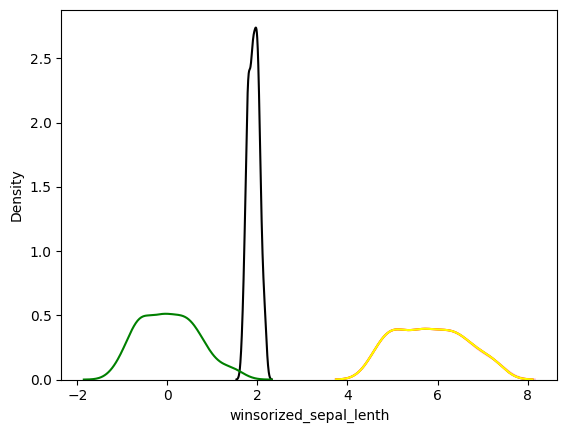

In [53]:
sns.kdeplot(df['winsorized_sepal_lenth'],color="pink")
sns.kdeplot(df['cliped_sepal_length'],color='red')
sns.kdeplot(df['log_sepal_length'],color='black')
sns.kdeplot(outliers,color='yellow')
sns.kdeplot(df['robust_data'],color='green')